<a href="https://colab.research.google.com/github/sinayavarian/Deep-Learning-HAR/blob/main/Alzymer_object_localization_and_image_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Classification and Object Localization in the Same Model

### The dataset

https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset_path = Path("/content/drive/MyDrive/AugmentedAlzheimerDataset")

class_names = sorted([
    folder.name
    for folder in dataset_path.iterdir()
    if folder.is_dir()
])

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

image_extensions = {".jpg", ".jpeg", ".png"}

image_paths = []
image_labels = []

for class_name in class_names:
    class_folder = dataset_path / class_name

    for image_path in class_folder.iterdir():
        if image_path.suffix.lower() in image_extensions:
            image_paths.append(str(image_path))
            image_labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
image_labels = np.array(image_labels)

image_paths, _, image_labels, _ = train_test_split(
    image_paths,
    image_labels,
    train_size=0.10,
    stratify=image_labels,
    random_state=42
)

dataset_size = len(image_paths)
n_classes = len(class_names)

print("Dataset size:", dataset_size)
print("Class names:", class_names)
print("Number of classes:", n_classes)

Dataset size: 3398
Class names: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Number of classes: 4


In [4]:
train_valid_paths, test_paths, train_valid_labels, test_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.10,
    random_state=42,
    stratify=image_labels
)

train_paths, valid_paths, train_labels, valid_labels = train_test_split(
    train_valid_paths,
    train_valid_labels,
    test_size=1/6,
    random_state=42,
    stratify=train_valid_labels
)


def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    return image, label


test_set_raw = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

valid_set_raw = tf.data.Dataset.from_tensor_slices(
    (valid_paths, valid_labels)
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_set_raw = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

print("Train images:", len(train_paths))
print("Validation images:", len(valid_paths))
print("Test images:", len(test_paths))

Train images: 2548
Validation images: 510
Test images: 340


In [5]:
batch_size = 32

train_set = train_set_raw.batch(batch_size)
valid_set = valid_set_raw.batch(batch_size)
test_set = test_set_raw.batch(batch_size)

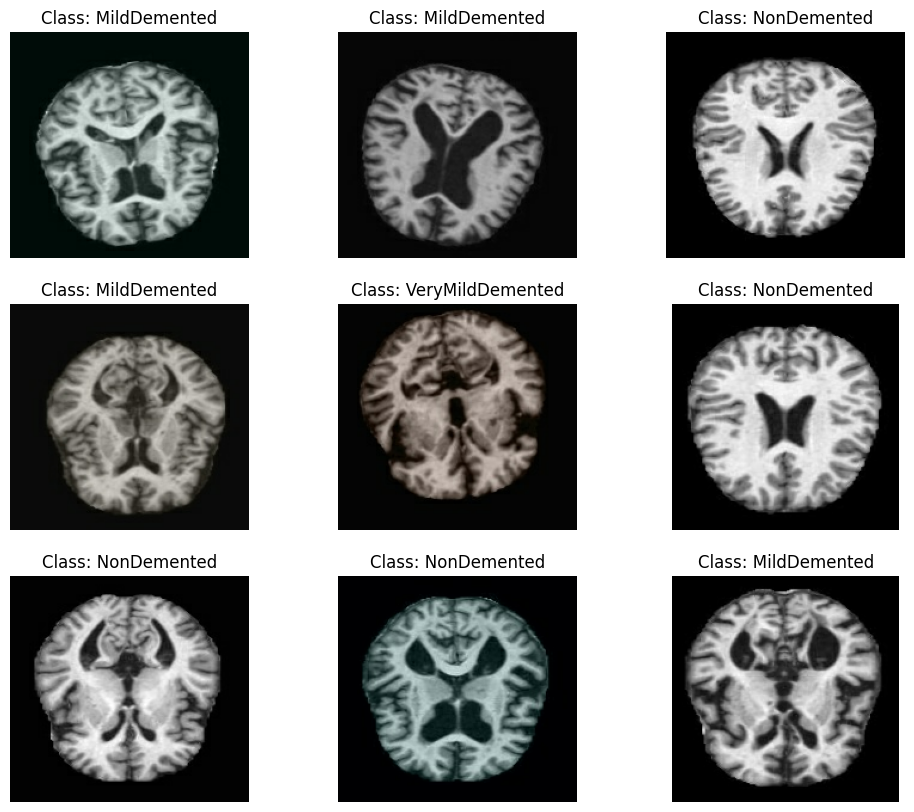

In [6]:
# extra code – displays the first 9 images in the validation set

plt.figure(figsize=(12, 10))
index = 0

for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[int(label.numpy())]}")
    plt.axis("off")

plt.show()

In [7]:
batch_size = 32

preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(
        height=224,
        width=224,
        crop_to_aspect_ratio=True
    ),
    tf.keras.layers.Lambda(
        tf.keras.applications.xception.preprocess_input
    )
])

train_set = train_set_raw.map(
    lambda X, y: (preprocess(X), y)
)

train_set = (
    train_set
    .shuffle(1000, seed=42)
    .batch(batch_size)
    .prefetch(1)
)

valid_set = valid_set_raw.map(
    lambda X, y: (preprocess(X), y)
).batch(batch_size)

test_set = test_set_raw.map(
    lambda X, y: (preprocess(X), y)
).batch(batch_size)

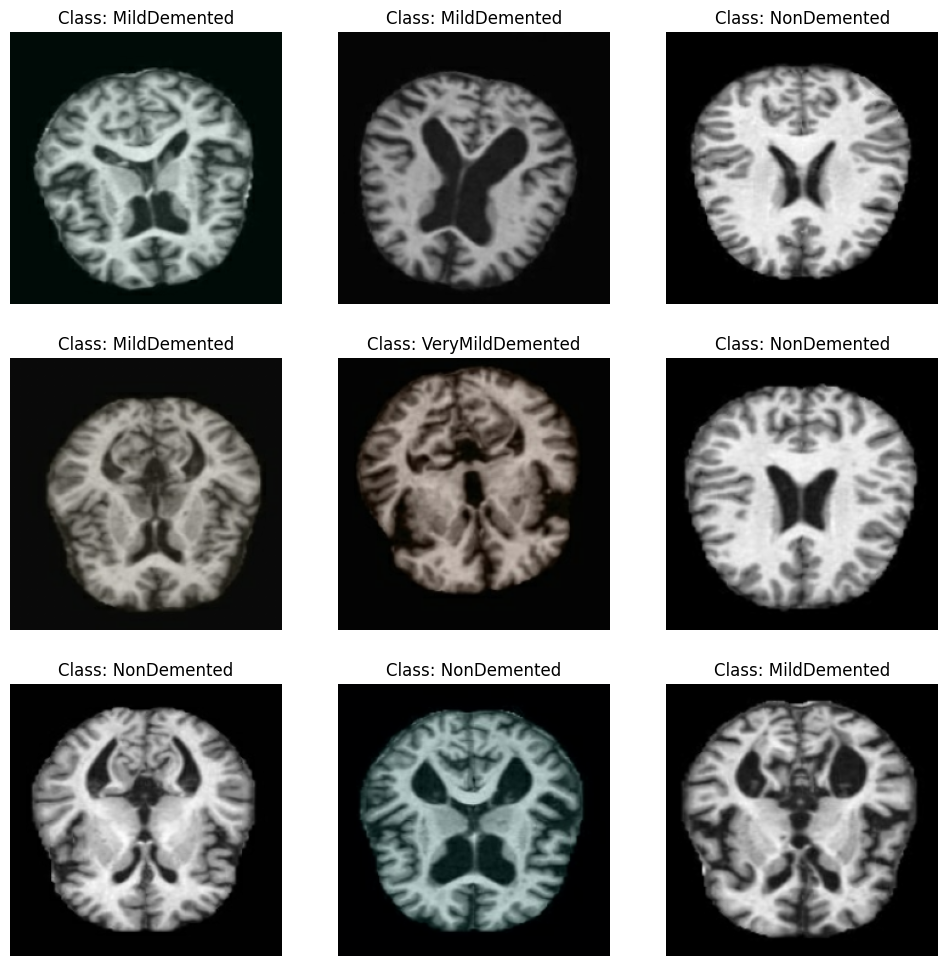

In [8]:
plt.figure(figsize=(12, 12))

for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)
        plt.title(f"Class: {class_names[int(y_batch[index].numpy())]}")
        plt.axis("off")

plt.show()

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

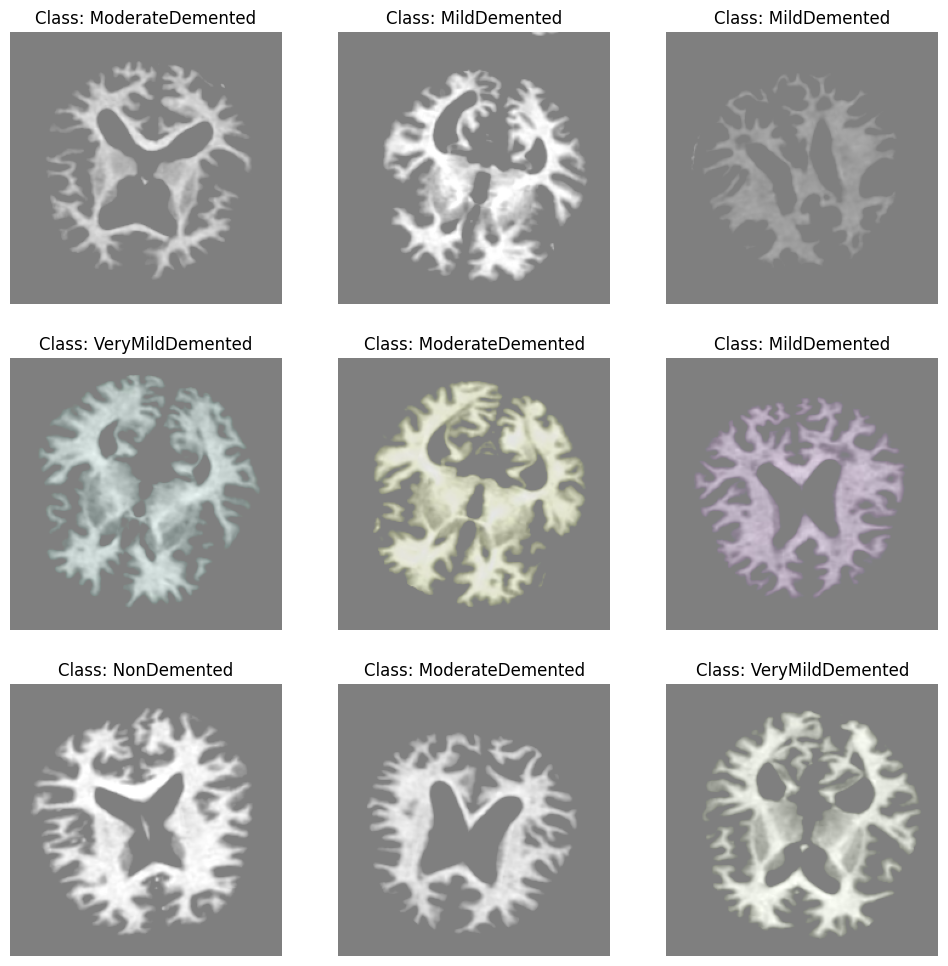

In [10]:
plt.figure(figsize=(12, 12))

for X_batch, y_batch in train_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)

    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch_augmented[index] + 1) / 2)
        plt.title(f"Class: {class_names[int(y_batch[index].numpy())]}")
        plt.axis("off")

plt.show()

# Classification and Localization

In [11]:
tf.random.set_seed(42)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

base_model = tf.keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False
)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

class_output = tf.keras.layers.Dense(
    n_classes,
    activation="softmax"
)(avg)

model = tf.keras.Model(
    inputs=base_model.input,
    outputs=class_output
)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [13]:
history = model.fit(
    train_set,
    validation_data=valid_set,
    epochs=2
)

Epoch 1/2
80/80 ━━━━━━━━━━━━━━━━━━━━ 555s 7s/step - accuracy: 0.5655 - loss: 0.9795 - val_accuracy: 0.3373 - val_loss: 1.6392
Epoch 2/2
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 525ms/step - accuracy: 0.8116 - loss: 0.4691 - val_accuracy: 0.6627 - val_loss: 0.8274


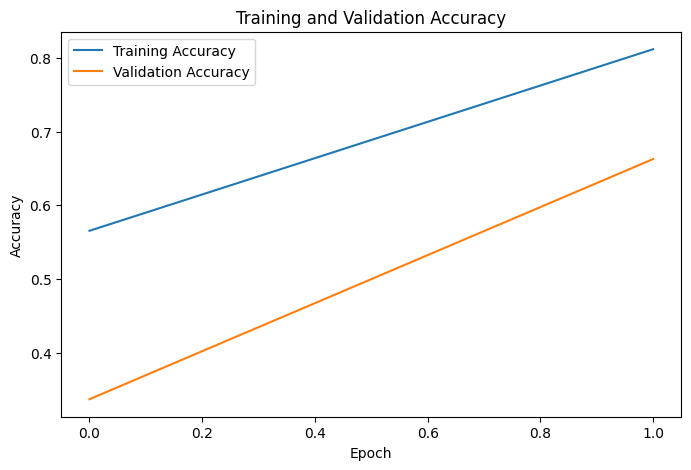

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

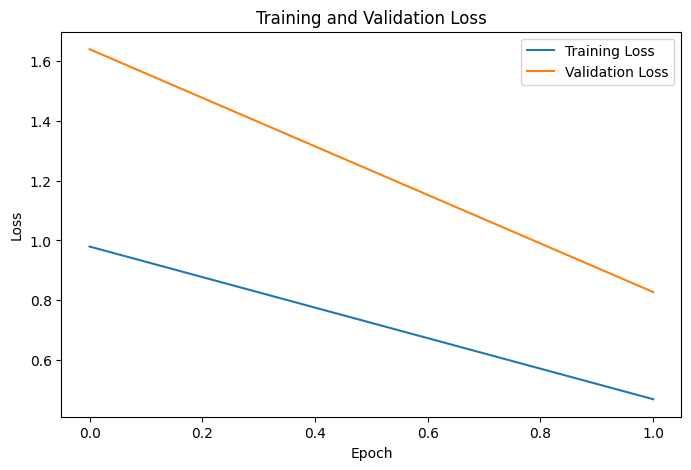

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 100s 9s/step - accuracy: 0.7000 - loss: 0.7654
Test Loss: 0.7654239535331726
Test Accuracy: 0.699999988079071


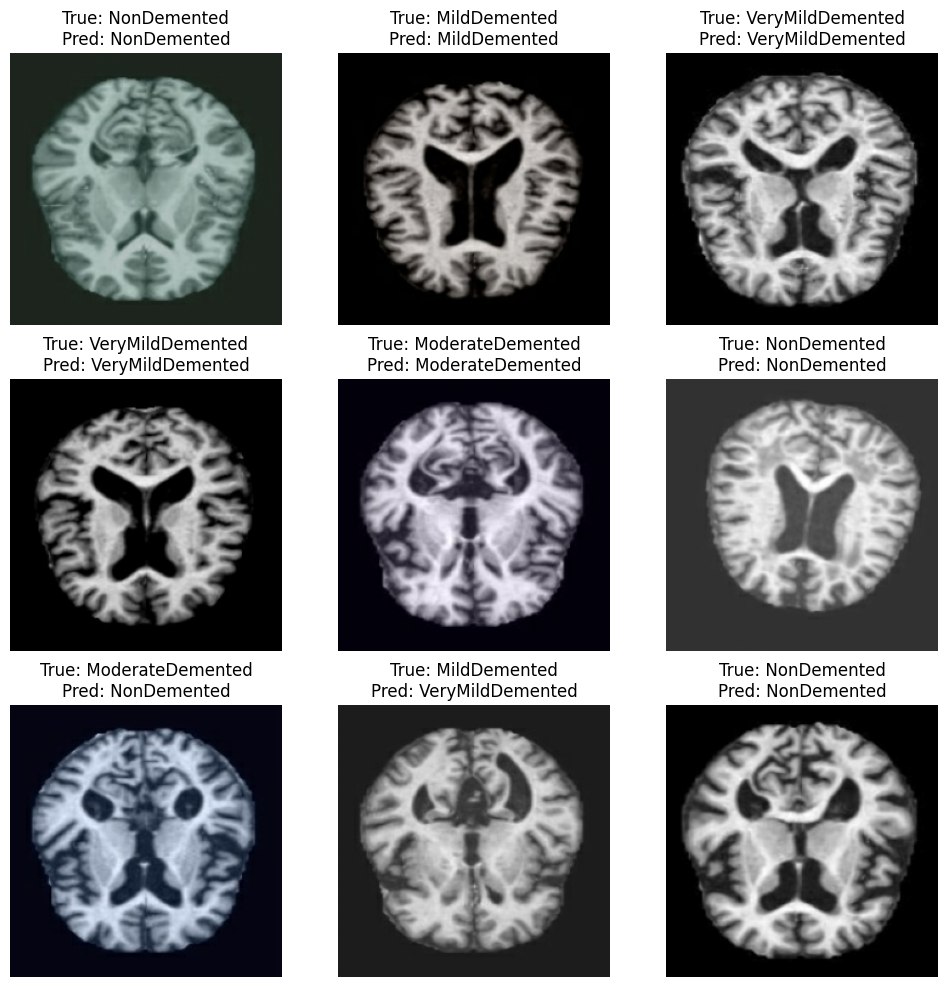

In [17]:
plt.figure(figsize=(12,12))

for images, labels in test_set.take(1):

    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        plt.subplot(3,3,i+1)

        plt.imshow((images[i] + 1) / 2)

        true_label = class_names[int(labels[i])]
        pred_label = class_names[predicted_labels[i]]

        plt.title(f"True: {true_label}\nPred: {pred_label}")

        plt.axis("off")

plt.show()